## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [8]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v7.csv"))

---

## Part 3 — Shape, Size, and Structure

---

<div style="width: 1200px">

In Part 2, we discovered that galaxies split into two distinct colour populations: a blue, star-forming cloud and a red, quenched sequence, with surprisingly few galaxies in between. Just colour tells us quite a bit about a galaxy's evolutionary state. But it raises an immediate question:

<br>

<center>
<span style="
border: 2px solid #DDDDDD;
padding: 10px;
font-size: 25px;
font-style: italic;">
"Does a galaxy's shape also tell us about a galaxy's evolutionary state?"</span>
</center>

<br>

Intuitively, we might expect that blue star-forming galaxies look different from red quenched ones. And indeed they do:

* Spiral galaxies are the most distinctive, and they're kind you've probably seen the most of. These tend to be bluer

* On the other hand, elliptical galaxies are smooth and featureless, and tend to be red.

* However, this relationship is not perfect, and there are certainly quite a few exceptions which are pretty scientifically interesting.

In this notebook, we'll start to explore the **structure** of galaxies, including how spread out the light is, how centrally concentrated the galaxy is, and how these properties relate to evolutionary state.

</div>

---

### Features of Galaxies

---

If we're going to analyse the structures of galaxies, we need to begin with understanding their features, and the different parts of a galaxy that we can use to distinguish different types.

| Feature | Details |
|---------|---------|
| Bulge | Dense central region which hosts the supermassive black hole. |
| Bar | Elongated structure of stars and gas passing through the bulge. These channel gas toward the centre, fuelling star formation and AGN activity. |
| Disk | Flat, extended plane containing the majority of a galaxy's stars, gas, and dust. |
| Spiral Arms | The "spiraly bits" within the disc. |
| Stellar Halo | Diffuse, spherical cloud of old, metal-poor stars and globular clusters surrounding the disc. |
| Dark Matter Halo | Invisible cloud covering the entire galaxy. It accounts for about 85% of the galaxy's total mass. |
| Supermassive Black Hole (SMBH) | A huge black hole which sits in the middle of the galaxy. |
| Globular Clusters | Gravitationally bound collections of old stars orbiting in the halo and bulge. The Milky Way hosts about 150. |
| Interstellar Medium | A mixture of gas and dust around the disc. |
| Nuclear Star Cluster | Extremely dense star cluster at the galactic nucleus, often coexisting with the SMBH. |

<div style="width: 1200px">
<img src="images/anatomy_mw.png"></img>
<center>
<i>Credit: NASA</i>
</center>

<br>

</div>

---

### Galaxy Morphology and the Hubble Tuning Fork

---


<div style="width: 1200px">

Now the next thing we need to know about galaxies is how they are classified. The systematic classification of galaxy shapes began in the 1920s with Edwin Hubble, who organised different galaxy types and forms into the **Hubble Tuning Fork**, which is one of the most iconic diagrams in astronomy.

The diagram arranges galaxies along two axes:

* **Left -> right:** As you move along from left to right, galaxies change from smooth, featureless ellipticals to disc-dominated spirals with open, patchy arms. Also, the bulges shrink, the disc grows, and star formation increases a lot.
* **The fork split:** Then, as per the name, the Hubble tuning fork separates normal spirals (which are found in the top arm), from barred spirals (on the bottom arm). These barred spiral galaxies feature a straight stellar bar through the centre from which the arms emerge. About half of all disc galaxies, including the Milky Way, are barred.

The different classes also have special names:

| **Class** | **Name** | **Key features** |
|-------|------|--------------|
| E0–E7 | Ellipticals | These galaxies are smooth, and, based on the number, are in between round and elongated, with no disc or arms. In elliptical galaxies, there are mostly old red stars, and there's essentially no star formation. |
| S0 | Lenticular | Lenticular galaxies are a weird intermediate galaxies, and they usually have a disc but no spiral arms. They have a reasonable amount of star formation and are the bridge between ellipticals and spirals. |
| Sa -> Sc | Spirals | Spiral galaxies have a prominent disc structure with arms. As you increase from Sa to Sc, the galaxy's bulge shrinks and the arms open. These galaxies have very high amounts of star formation and tend to have mostly young blue stars. |
| SBa -> SBc | Barred spirals | Barred spirals are very similar to spiral galaxies, but also have a central stellar bar. They also have different types based on the amount of bulge and the types of spiral arms. |

<br>

> **A common misconception:**

> Hubble called elliptical galaxies "early-type" and spirals "late-type", implying that galaxies evolve from left to right. We now know this is wrong, and if anything, spirals tend to turn *into* ellipticals over time, not the reverse. The "early/late" labels have unfortunately stuck in the literature, but keep in mind that it doesn't correlate to the galaxy's age.

The interactive diagram below allows you to explore the full tuning fork. You can click any class to see its main features and some measurements that we're going to use throughout this section:

</div>

In [9]:
from IPython.display import HTML # Import HTML for display

HTML(graphs.hubble_fork()) # Display the Hubble fork diagram

<div style="width: 1200px">

<center>
<i>Credit: NASA, ESA, Göran Nilsson</i>
<center>

</div>

---

<br>

<div style="width: 1200px">

Now there's just one more morphological type worth knowing: **irregular galaxies**.

Irregulars don't fit the tuning fork at all. They are chaotic, asymmetric, and intensely star-forming, such as the Large and Small Magellanic Clouds. At higher redshifts, irregular morphologies become much more common, reflecting the pretty violent early universe.

</div>

---

### The Petrosian Radius

---

<div style="width: 1200px">

Okay great! So now that we know the different types of galaxies and their features, another fundamental part of structure is **size**.

However, measuring the size of a galaxy is harder than it sounds. Unlike a ball with a clear edge, galaxies fade into the background and there's no sharp boundary where a galaxy ends and empty space begins. So, we need a robust, distance-independent way to define "how big" a galaxy is.

The solution that the SDSS uses is called the **Petrosian radius**, and the idea is pretty elegant. Rather than asking "where does the galaxy end?", we ask:

"At what radius does the galaxy's surface brightness drop to a fixed fraction of the average brightness inside that radius?"

Okay that might sound a bit convoluted but all it says is:


<div style="width: 250px;
            display: inline-block;
            margin-right: 50px">

<img src="images/annulus.webp"></img>
<center>
<i>Credit: Geeks for Geeks</i>
</center>

</div>

<div style="width: 850px;
            display: inline-block">

Step 1. Choose a radius which we will call $r$, and make a circle of radius $r$ to "sit on top of the galaxy".

Step 2. Calculate the average brightness of everything inside that radius $r$ circle.

Step 3. Make a thick-ish ring around $r$ (called an *annulus*) and calculate the average brightness inside that ring.*

Step 4. Calculate the ratio between the edge brightness and the inside brightness: $\text{ratio} = \frac{\text{edge brightness}}{\text{inside brightness}}$

Step 5. When $\text{ratio} = 0.2$, then that $r$ is the Petrosian radius.

<br>

</div>

<br>

<br>

<div style="width: 750px;
            display: inline-block;
            margin-right: 50px">

I hope you understood that, but if you didn't, that's totally okay, and you can just think of the Petrosian radius as the size of the galaxy.

<br>

But why does this even matter? Why couldn't we have a simpler definition? Well, we definitely could have made it a lot simpler, but the special thing about the Petrosian radius is that it is **independent of distance**, so a galaxy at $z = 0.05$ and the same galaxy at $z = 0.15$ will give the same Petrosian radius in physical units (probably **kiloparsecs****), even though the more distant one appears smaller on the sky. This makes it ideal for comparing galaxy sizes in the SDSS, where we have galaxies at different distances.

In our dataset, this Petrosian radius is stored as `petroRad_r`, and is measured in the $r$ band, in arcseconds (1 arcsecond is 1/3600 of a degree). However, this angle only gives us apparent size, and we'll need to convert it to physical units later on (like the previously mentioned kiloparsec).

</div>

<div style="width: 400px;
            display: inline-block">
<img src="images/petrosian_r.jpg"></img>
<center>
<i>Credit: Michael Richmond</i>
</center>
</div>

<div style="width: 1200px">

We also have access to something called **Petrosian flux**, which is basically how bright the galaxy is. It's calculated by multiplying the total brightness or flux inside the Petrosian radius by some number, which is typically something like 2 or 2.5. Now this is pretty useful, but its even more usable if its in a format called `petroMag_r`, or Petrosian magnitude. The Petrosian magnitude is essentially a logarithmic version of the Petrosian flux, which more accurately reprents how we humans see light, and lets us compare brightness with external sources more easily.

Two other size measurements also appear in the data:

* **`petroR50`**: the radius enclosing 50% of the total Petrosian flux
* **`petroR90`**: the radius enclosing 90% of the total Petrosian flux

<br><br>

**For those of you who are extra curious, this annulus is defined to have its edges at 80% of the radius and 125% of the radius. So, for example, if our radius was 5, then the annulus would be the region in between a circle of radius 4 and a circle of radius 6.25.*

***A kiloparsec is a unit of distance equal to about 30 million billion kilometres, or the distance that light travels in 3,260 years*

</div>

---

### The Concentration Index

---


<div style="width: 1200px">

Now the size of a galaxy is helpful and all, but knowing *where* the light is distributed tells us something a lot more interesting about its structure.

The **concentration index** $C$ captures this:

$$C = 5 \times \log_{10}\left(\frac{r_{90}}{r_{50}}\right)$$

where $r_{90}$ is the radius containing 90% of the light and $r_{50}$ is the radius containing 50% of the light. A galaxy where the light is tightly packed into the centre has a large $r_{90}/r_{50}$ ratio, since most of the light is already captured within $r_{50}$, so you need to go much further out to get the remaining 40%. On the other hand, a galaxy where the light is spread smoothly across the disc has a smaller ratio.

So this means that:

* **$C \gtrsim 3.0$**: highly concentrated, bulge-dominated galaxies: **elliptical galaxies**
* **$C \approx 2.1$–$3.0$**: intermediate concentration: **lenticular (S0) galaxies**  
* **$C \lesssim 2.1$**: diffuse, more disc-dominated galaxies: **spiral galaxies**

This single number is so awesome because it gives us a pretty easy way to morphologically classify a galaxy without ever looking at an image!

</div>

Okay, lets actually look at our own data to see what the concentration index can tell us!

---

### Setting Up

---

We'll start by setting up the necessary imports:

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

<div style="width: 1200px">

Then, let's prepare the data by selecting our low-redshift subset and splitting the galaxies into their colour category (which is what we explored last chapter):

</div>

In [11]:
galaxies = sdss._galaxies_extended()

# Trim to physically sensible ranges
galaxies = galaxies[(galaxies["g_r"] > -0.2) & (galaxies["g_r"] < 1.4) &(galaxies["petroRad_r"] < 200)].copy()

# z < 0.045 subset for colour-reliable plots
gal_lowz = galaxies[galaxies["redshift"] < 0.045].copy()

# Colour classes based on g-r thresholds
gal_lowz["colour_class"] = pd.cut(gal_lowz["g_r"], bins=[-np.inf, 0.58, 0.76, np.inf], labels=["Blue Cloud", "Green Valley", "Red Sequence"])

blue = gal_lowz[gal_lowz["colour_class"] == "Blue Cloud"]
green = gal_lowz[gal_lowz["colour_class"] == "Green Valley"]
red  = gal_lowz[gal_lowz["colour_class"] == "Red Sequence"]

---

### Plot 1: Concentration Index by Colour Class

---


<div style="width: 1200px">

If galaxy colour and morphology are genuinely linked, as we saw previously with the Hubble Classification, then blue and red galaxies should have systematically different concentration indices. Let's see if that really is the case:

</div>

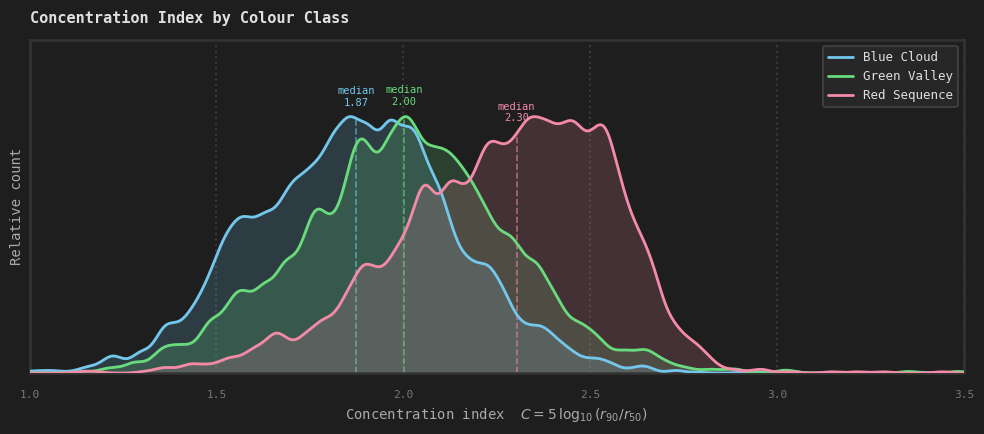

In [ ]:
# Set up the plot
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Set an appropriate x-range
x_range = np.linspace(1, 3.5, 800)

# Set the colour and label for each population
populations = [(blue,  "#74c7ec", "Blue Cloud"), (green, "#69db7c", "Green Valley"), (red,   "#f38ba8", "Red Sequence"),]

# Plot the KDE for each population
for pop, colour, label in populations:
    c_vals = pop["C"].dropna().values # Get the concentration index values
    kde = gaussian_kde(c_vals, bw_method=0.08) # Set KDE parameters
    kde_vals = kde(x_range)
    kde_vals = kde_vals / kde_vals.max()
    ax.fill_between(x_range, 0, kde_vals, color=colour, alpha=0.18, zorder=2) # Fill under the curve
    ax.plot(x_range, kde_vals, lw=2, color=colour, label=label, zorder=3) # Plot the KDE line
    med = np.median(c_vals) # Calculate the median
    med_h = kde([med])[0] / kde(x_range).max() # Get the KDE value at the median and normalise it
    ax.vlines(med, 0, med_h, color=colour, lw=1.2, linestyle="--", alpha=0.6) # Add a vertical line at the median
    ax.text(med, med_h + 0.04, f"median\n{med:.2f}", color=colour, fontsize=7.5, ha="center", va="bottom") # Annotate the median value

# Final plot formatting
ax.set_xlim(1, 3.5)
ax.set_ylim(0, 1.3)
ax.set_yticks([])
ax.set_xlabel(r"Concentration index  $C = 5\,\log_{10}(r_{90}/r_{50})$", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative count", color="#aaaaaa", fontsize=10)
ax.set_title("Concentration Index by Colour Class", color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor("#333333")

# Display the plot
plt.tight_layout()
plt.show()

<div style="width: 1200px">

Okay, we can pretty easily and clearly see the separation of the three "classes" of galaxies, and their differing distributions of $C$ values:

* **Blue Cloud galaxies** tend to peak at lower $C$ (in our data, at about $C=1.87$). This is because their light is spread across an extended disc, as shown previously with galaxy morphology and the Hubble tuning fork.

* **Red Sequence galaxies** usually peak at significantly higher $C$ (about $2.30$), since their light is tightly concentrated toward the centre. This high $C$ behaviour is typical of elliptical galaxies that have used up or expelled their gas and settled into a smooth, compact structure, resulting in the graph that we can see.

* **Green Valley galaxies** are in between, with a pretty broad distribution spanning both morphological types. This is consistent with the idea that these are transitioning galaxies, so some may have already developed a dominant bulge while still retaining some disc structure, while others may be discs whose star formation is being quenched without a major structural transformation.

</div>

---

### The "Four Quadrants": Concentration vs Colour

---


<div style="width: 1200px">

So from the previous plot that we created, we can see that colour and morphology are correlated through the concentration index. But it told us nothing about how tight that relationship is, and what kind of outliers there are and their significance.

One natural way to visualise this relationship more deeply is by plotting concentration against $g - r$ colour directly. This will create a 2D map with four naturally defined **quadrants**, each representing a different kind of galaxy. Of course, these lines don't represent a hard division where anything on the left is of type X and anything on the right is type Y, and nor are there any preset location of these lines, but they can still give us a good understanding of different galaxy types defined by colour and structure.

| Quadrant | Colour | Concentration | Interpretation |
|----------|--------|---------------|----------------|
| Bottom-left | Blue | Low | These are classic **spiral galaxies** which are disc-dominated and actively star-forming |
| Top-right | Red | High | These are classic **elliptical galaxies** which are bulge-dominated and quenched |
| Top-left | Blue | High | This section represents **Compact star-forming galaxies**. These are very rare, and are often the result of two young galaxies colliding and merging |
| Bottom-right | Red | Low | **Passive disc galaxies** are quenched but the disc structure of blue galaxies is still retained |

The top-left and bottom-right quadrants are, I think, the most scientifically interesting, since they represent galaxies where colour and morphology don't align very well, hinting at different possible quenching pathways that a galaxy might take.

</div>

<div style="width: 1200px">

<center>
<img width=200px src="images/hubble_fork/tf_SBc.jpg"></img>
<img width=201px src="images/hubble_fork/tf_E3.jpg"></img>
<img width=212px src="images/csfg.webp"></img>
<img width=196px src="images/anemic.jpg"></img>

<i><b>LEFT-RIGHT</b>: Spiral Galaxy (Göran Nilsson), Elliptical Galaxy (NASA), Compact Star-Forming Galaxy (NBC), Passive Disc / Anemic Galaxy (Wikipedia)</i>
</center>

</div>

Anyway, let's plot these "four quadrants":

/tmp/ipykernel_32162/535287512.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


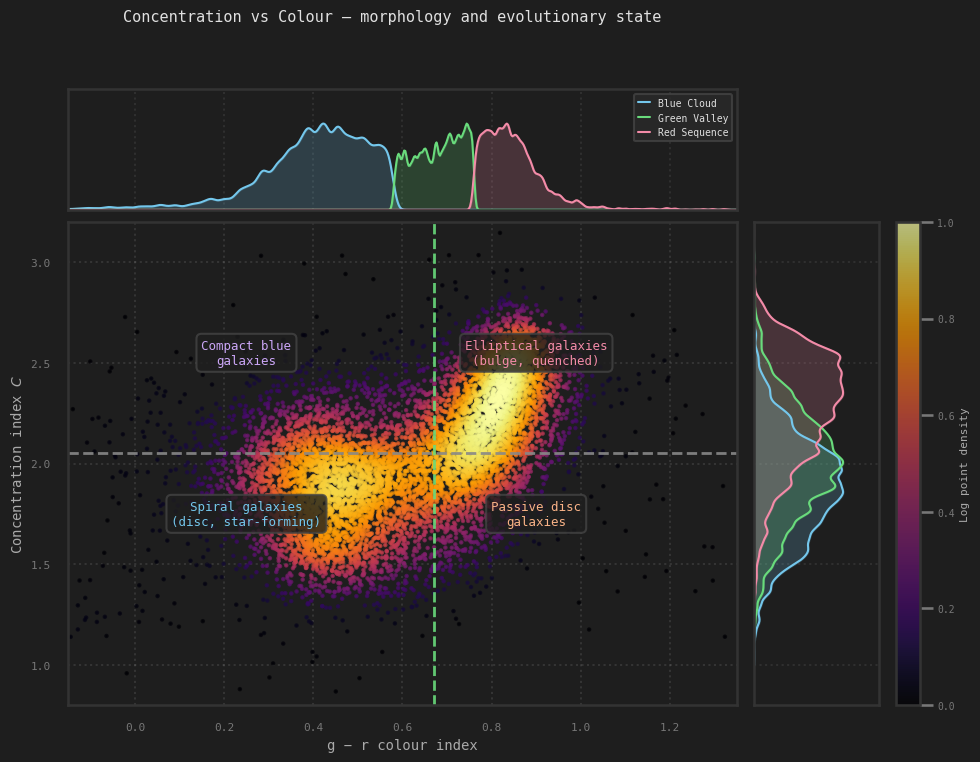

In [26]:
sample = gal_lowz.sample(min(30000, len(gal_lowz)), random_state=67) # Take a random sample for the scatter plot

# Set the x and y values for the scatter plot
x = sample["g_r"].values
y = sample["C"].values

# Calculate the point density for the scatter plot
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
sort_idx = density.argsort()
x, y, density = x[sort_idx], y[sort_idx], density[sort_idx]
log_density = np.log1p(density) # Use logarithmic scale
log_density = (log_density - log_density.min()) / (log_density.max() - log_density.min())

# Quadrant boundaries
c_split  = 2.05   # concentration boundary
gr_split = 0.67   # colour boundary (green valley centre)

# Set up the figure with a main scatter plot and two marginal KDE plots
fig = plt.figure(figsize=(11, 8), facecolor="#1e1e1e")
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.04, wspace=0.04)
ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# Set dark background for all axes
for ax in [ax_main, ax_top, ax_right]:
    ax.set_facecolor("#1e1e1e")

sc = ax_main.scatter(x, y, c=log_density, s=3, alpha=0.7, cmap="inferno", rasterized=True) # Scatter plot with log-scaled density colouring

label_props = dict(fontsize=9, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.4", fc="#1e1e1e", ec="#444444", alpha=0.80)) # Properties for the quadrant labels

# Quadrant dividers
ax_main.axvline(gr_split, color="#69db7c", lw=2, linestyle="--", alpha=0.9) # Colour boundary
ax_main.axhline(c_split,  color="#888888", lw=2, linestyle="--", alpha=0.9) # Concentration boundary

# Quadrant labels
ax_main.text(0.25, 1.75, "Spiral galaxies\n(disc, star-forming)", color="#74c7ec", **label_props) # Spiral galaxies
ax_main.text(0.90, 2.55, "Elliptical galaxies\n(bulge, quenched)", color="#f38ba8", **label_props) # Elliptical galaxies
ax_main.text(0.25, 2.55, "Compact blue\ngalaxies", color="#cba6f7", **label_props) # Compact blue galaxies
ax_main.text(0.90, 1.75, "Passive disc\ngalaxies", color="#fab387", **label_props) # Passive disc galaxies

# TOP KDE PLOT: G-R DISTRIBUTION SPLIT BY COLOUR CLASS
x_range_gr = np.linspace(-0.15, 1.35, 600) # Set the x-range

# Plot the KDE for each colour class on the top marginal plot
for pop, color, label in [(blue, "#74c7ec", "Blue Cloud"), (green, "#69db7c", "Green Valley"), (red, "#f38ba8", "Red Sequence")]:
    vals = pop["g_r"].dropna().values
    kde = gaussian_kde(vals, bw_method=0.07) # Calculate KDE with a specified bandwidth
    k = kde(x_range_gr); k /= k.max()
    ax_top.fill_between(x_range_gr, 0, k, color=color, alpha=0.20) # Fill under the KDE curve
    ax_top.plot(x_range_gr, k, color=color, lw=1.5, label=label) # Plot the KDE line

# Final formatting for the top KDE plot
ax_top.set_yticks([])
ax_top.tick_params(labelbottom=False, colors="#777777", labelsize=7)
ax_top.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=7, loc="upper right", handlelength=1.2)
ax_top.set_ylim(0, 1.4)
ax_top.grid(True, linestyle=":", alpha=0.08, color="#ffffff")
for spine in ax_top.spines.values(): spine.set_edgecolor("#333333")

# RIGHT KDE PLOT: C DISTRIBUTION SPLIT BY COLOUR CLASS
x_range_c = np.linspace(1.0, 3.6, 600) # Set the x-range

for pop, color in [(blue, "#74c7ec"), (green, "#69db7c"), (red, "#f38ba8")]:
    vals = pop["C"].dropna().values
    kde = gaussian_kde(vals, bw_method=0.08) # Calculate KDE with a specified bandwidth
    k = kde(x_range_c); k /= k.max()
    ax_right.fill_betweenx(x_range_c, 0, k, color=color, alpha=0.20) # Fill under the KDE curve
    ax_right.plot(k, x_range_c, color=color, lw=1.5) # Plot the KDE line

# Final formatting for the right KDE plot
ax_right.set_xticks([])
ax_right.tick_params(labelleft=False, colors="#777777", labelsize=7)
ax_right.set_xlim(0, 1.4)
ax_right.grid(True, linestyle=":", alpha=0.08, color="#ffffff")
for spine in ax_right.spines.values(): spine.set_edgecolor("#333333")

# Create the colourbar
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Log point density", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

# Final formatting for the main scatter plot
ax_main.set_xlim(-0.15, 1.35)
ax_main.set_ylim(0.8, 3.2)
ax_main.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
ax_main.set_ylabel(r"Concentration index $C$", color="#aaaaaa", fontsize=10)
ax_main.tick_params(colors="#777777", labelsize=8)
ax_main.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
for spine in ax_main.spines.values():
    spine.set_edgecolor("#333333")


# Add a main title for the entire figure
fig.suptitle("Concentration vs Colour — morphology and evolutionary state",
             color="#e0e0e0", fontsize=11, x=0.42, y=0.98)

# Display the plot
plt.tight_layout()
plt.show()

<div style="width: 1200px">

Okay awesome! So in case you're a bit overwhelmed by this plot, we are essentially making a scatter plot of a bunch of galaxies which are represented as a point with an x-coordinate based on its colour and a y-coordinate based on its concentration index. The brighter the area, the more dense that area is. Then, on the top and right, there are line graphs which show the actual distribution of galaxies based on colour or concentration.

The density map reveals the two main populations of galaxies as bright concentrations in the bottom-left (blue, diffuse spirals) and top-right (red, compact ellipticals) quadrants. The diagonal emptiness between them corresponds to the green valley.

Now the two off-diagonal quadrants are comparatively pretty sparsely populated, but they're scientifically quite interesting:

* **Top-left (blue and compact):** These are rare galaxies and probably compact star-forming systems. These kinds of galaxies are often triggered by merging galaxies that ignited a burst of star formation. Other possible galaxies which could fit into this category are early-type galaxies that recently accreted cold gas, so they are still small and compact, but very blue from high star formation.

* **Bottom-right (red and diffuse):** These are **passive disc galaxies**, which are sometimes called S0 or lenticular galaxies. They have retained their disc structure, maybe through a gentle, internal quenching process, but have stopped forming stars. These galaxies have undergone quenching but surprisingly no dramatic structural transformation.

This last point is pretty important: **you can quench a galaxy without destroying its disc**. The existence of the bottom-right quadrant shows us that quenching mechanisms must also include gentle, internal processes, not just violent events.

</div>

---

### The de Vaucouleurs Fraction: Disc vs Bulge

---


<div style="width: 930px;
            display: inline-block;
            margin-right: 50px">

I feel like we've given a lot of attention to the concentration index $C$, but there are actually lots of other very useful measures of galaxy structure.

The column `fracDeV_r` gives us something complementary to the concentration index. It's a direct measure of how bulge-like vs disc-like the galaxy's light profile is. This is determined by attempting to "fit" two standard profile shapes to the galaxy, and seeing how well the galaxy "fits" the typical shape of a bulge or disc galaxy. This "fitting" process actualy turns out to be quite useful in a lot of areas of science, when you want to know exactly how much an object conforms to some "ideal" category.

Now for `fracDeV_r`, a value of `1.0` means that the light is best described by a **de Vaucouleurs profile**. This means a compact, centrally concentrated, and elliptical-like galaxy. A value of `0.0` means the light follows an exponential disc profile, which is the exact opposite of what was just mentioned: a diffuse, spiral-like galaxy. Values in between `0` and `1` represent mixed systems.

Importantly, `fracDeV_r` is determined from the *shape* of the light profile rather than just its spatial extent, making it an independent morphological measurement from $C$. Plotting the two against each other can allow us to test whether they are correlated.

Let's have a look.

</div>

<div style="width: 220px;
            display: inline-block">
<img src="images/deV.jpg"></img>
<center>
<i>Gérard de Vaucouleurs, a French astronomer. Credit: Wikipedia</i>
</center>
</div>

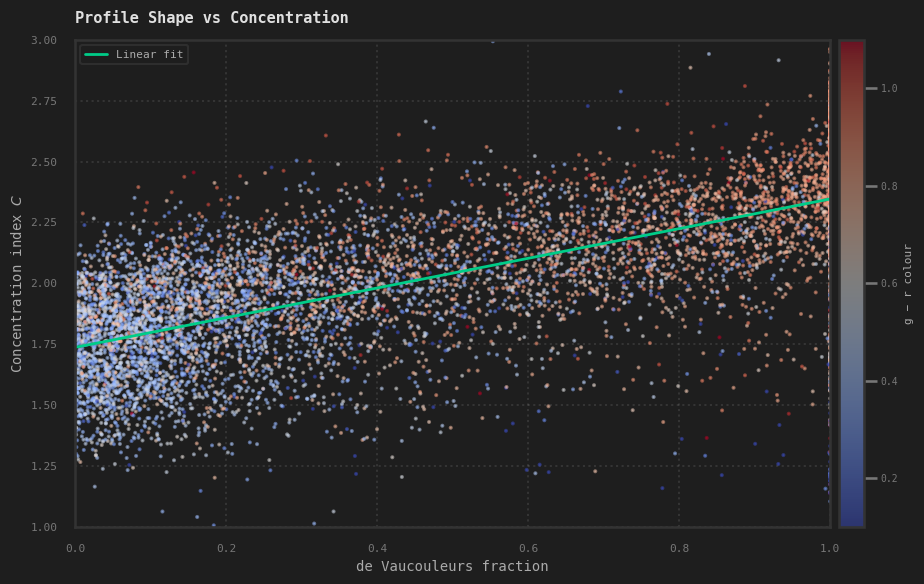

In [27]:
sample_fdev = gal_lowz.sample(min(25000, len(gal_lowz)), random_state=67) # Take a random sample for the scatter plot

# Set the x and y values for the scatter plot
x = sample_fdev["fracDeV_r"].values
y = sample_fdev["C"].values

# Set the colour based on g-r
c = sample_fdev["g_r"].values

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Make a linear fit to the data (regression line)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(0, 1, 100) # Generate x values
y_line = m * x_line + b # Calculate corresponding y values for the regression line
ax.plot(x_line, y_line, color="#00cc88", linewidth=2, label="Linear fit") # Plot the regression line
ax.legend(facecolor="#1e1e1e", edgecolor="#333333", labelcolor="#aaaaaa", fontsize=8) # Add a legend for the regression line

# Scatter plot with g-r colour coding
sc = ax.scatter(x, y, c=c, cmap="coolwarm", vmin=0.1, vmax=1.1, s=2, alpha=0.5, rasterized=True)
# Create the colourbar
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("g − r colour", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

# Final formatting
ax.set_xlabel("de Vaucouleurs fraction", color="#aaaaaa", fontsize=10)
ax.set_ylabel(r"Concentration index $C$", color="#aaaaaa", fontsize=10)
ax.set_title("Profile Shape vs Concentration", color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(1, 3)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

From this we can see that the two morphological measurements are very correlated. Galaxies with high `fracDeV_r` (bulge-like profiles) also tend to have high $C$ (centrally concentrated light), and they are coloured red. Galaxies with low `fracDeV_r` (disc-like profiles) tend to have low $C$ and are coloured blue.

This agreement isn't super strong (the green line on the plot is only slightly tilted), but it's very reassuring. It tells us that the morphological signal we're measuring is robust. The `fracDeV_r` parameter is derived from profile *shape* fitting, while $C$ is derived purely from the radii enclosing fixed light fractions. They are computed in completely different ways, yet they point to the same physical picture. Amazing.

You should also notice that `fracDeV_r` shows a **bimodal distribution**. Galaxies tend to cluster near `0` or near `1`, with fewer in the intermediate range. This mirrors the colour bimodality we saw in Part 2, and reinforces the idea that galaxy morphology, like colour, is not a smooth continuum but a bimodal distribution driven by distinct evolutionary pathways.

</div>

---

### What We've Learned

---


<div style="width: 1200px">

We've learnt quite a bit in this chapter, so let's do a quick recap:

* **The Hubble Tuning Fork organises galaxy morphology** into a sequence from ellipticals (red, concentrated, quenched) to spirals (blue, diffuse, star-forming), and our SDSS measurements reproduce this gradient quantitatively.

* **Colour and morphology are correlated but not identical.** Blue galaxies tend to be disc-dominated spirals and red galaxies tend to be bulge-dominated ellipticals, but the off-diagonal quadrants (passive discs and compact star-formers) tell us that quenching and structural transformation are not always the same process.

* **The concentration index $C$ is a powerful single-number morphological classifier.** It cleanly separates the blue and red populations in our sample, with green valley galaxies spanning both. This is consistent with a structural transformation happening alongside (or after) quenching.

* **The de Vaucouleurs fraction independently confirms the morphological idea.** Two different ways of measuring structure (profile shape and concentration) are correlated with each other and with colour.

In the next notebook, we'll move from structure to **distance** and **brightness**, and begin to find out how galaxy properties have evolved across cosmic history.

</div>